Loading data...
Total reviews loaded: 355,773
Date range: 2016-06-24 04:16:12 to 2026-05-25 04:50:17

=== OVERALL SENTIMENT DISTRIBUTION ===
Positive: 256,114 reviews (72.0%)
Negative: 87,169 reviews (24.5%)
Neutral: 12,490 reviews (3.5%)

Average Rating: 3.89/5

=== RECENT TREND (Last 30 days - 62 reviews) ===
Positive: 22.6%
Negative: 74.2%
Neutral: 3.2%

=== TOP THEMES IN NEGATIVE REVIEWS ===
account: 11501
they: 8416
when: 8348
even: 7150
from: 6760
update: 6672
your: 6343
good: 6002
please: 5889
there: 5681
what: 5622
back: 5441
time: 5265
post: 4915
been: 4863

=== TOP THEMES IN POSITIVE REVIEWS ===
good: 66059
nice: 36196
love: 10291
best: 9373
great: 8088
excellent: 4336
super: 4238
apps: 3974
friends: 3970
thank: 3966

✅ Analysis complete! Summary saved to 'sentiment_summary.csv'


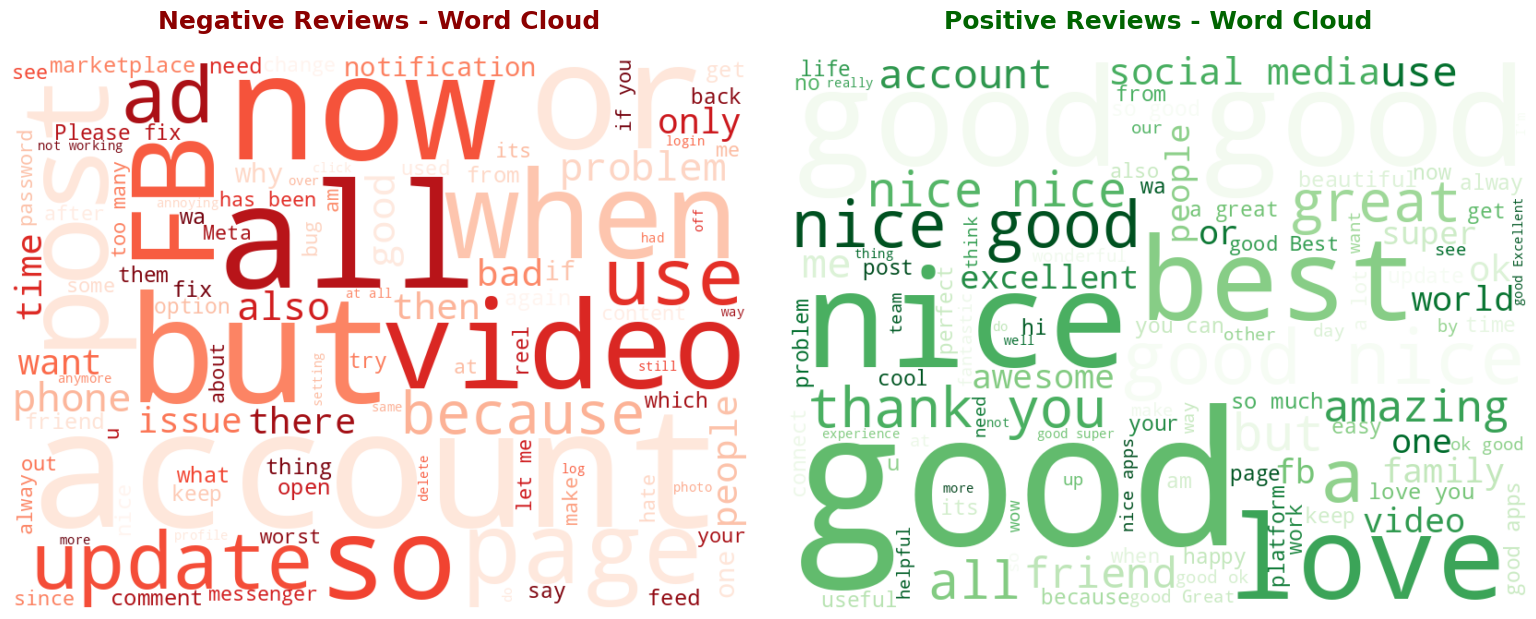


✅ Wordclouds saved to 'sentiment_wordclouds.png'


In [ ]:
# Load the library
import pandas as pd
import numpy as np
from datetime import datetime
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os
from wordcloud import WordCloud

# Define global stop words for WordCloud
global_stop_words = {'the', 'and', 'to', 'is', 'app', 'facebook', 'this', 'for', 'in', 'of', 'it', 'on', 'my', 'i', 'with', 'just', 'that', 'have', 'very', 'like'}

# ====================== LOAD DATA ======================
file_path = 'https://drive.google.com/uc?export=download&id=1hkAdJ3Bq9B_PTN6VR4mRuB7r3fg6b6Dp'

print("Loading data...")
df = pd.read_csv(file_path)

# Convert date
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df = df.dropna(subset=['content', 'score', 'at'])

print(f"Total reviews loaded: {len(df):,}")
print(f"Date range: {df['at'].min()} to {df['at'].max()}\n")

# ====================== SENTIMENT CLASSIFICATION ======================
def classify_sentiment(score, text=""):
    """Classify based on score + keyword reinforcement"""
    text_lower = str(text).lower()

    positive_words = ['good', 'great', 'love', 'best', 'excellent', 'nice', 'awesome', 'wonderful', 'perfect', 'happy']
    negative_words = ['bad', 'worst', 'hate', 'terrible', 'annoying', 'frustrating', 'suspended', 'disabled', 'bug', 'glitch', 'ads']

    pos_count = sum(1 for word in positive_words if word in text_lower)
    neg_count = sum(1 for word in negative_words if word in text_lower)

    if score >= 4:
        return 'Positive'
    elif score <= 2:
        return 'Negative'
    else:
        if pos_count > neg_count:
            return 'Positive'
        elif neg_count > pos_count:
            return 'Negative'
        else:
            return 'Neutral'

df['sentiment'] = df.apply(lambda row: classify_sentiment(row['score'], row['content']), axis=1)

# ====================== OVERALL ANALYSIS ======================
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

print("=== OVERALL SENTIMENT DISTRIBUTION ===")
for sent, count in sentiment_counts.items():
    print(f"{sent}: {count:,} reviews ({sentiment_pct[sent]:.1f}%)")

print(f"\nAverage Rating: {df['score'].mean():.2f}/5")

# ====================== RECENT TREND (Last 30 days) ======================
latest_date = df['at'].max()
thirty_days_ago = latest_date - pd.Timedelta(days=30)

recent = df[df['at'] >= thirty_days_ago]

print(f"\n=== RECENT TREND (Last 30 days - {len(recent):,} reviews) ===")
recent_sent = recent['sentiment'].value_counts(normalize=True) * 100
for sent in ['Positive', 'Negative', 'Neutral']:
    print(f"{sent}: {recent_sent.get(sent, 0):.1f}%")

# ====================== KEY THEMES EXTRACTION ======================
def extract_themes(text_series, n=20):
    text = ' '.join(text_series.str.lower())
    words = re.findall(r'\b\w+\b', text)
    # Use global_stop_words here as well, or modify it to be more specific.
    # For consistency with WordCloud, we'll use the global one.
    filtered = [w for w in words if w not in global_stop_words and len(w) > 3]
    return Counter(filtered).most_common(n)

print("\n=== TOP THEMES IN NEGATIVE REVIEWS ===")
neg_reviews = df[df['sentiment'] == 'Negative']['content']
neg_themes = extract_themes(neg_reviews, 15)
for word, count in neg_themes:
    print(f"{word}: {count}")

print("\n=== TOP THEMES IN POSITIVE REVIEWS ===")
pos_reviews = df[df['sentiment'] == 'Positive']['content']
pos_themes = extract_themes(pos_reviews, 10)
for word, count in pos_themes:
    print(f"{word}: {count}")

# ====================== SAVE RESULTS ======================
summary = {
    'total_reviews': len(df),
    'avg_rating': df['score'].mean(),
    'positive_pct': sentiment_pct.get('Positive', 0),
    'negative_pct': sentiment_pct.get('Negative', 0),
    'recent_negative_pct': recent_sent.get('Negative', 0)
}

summary_df = pd.DataFrame([summary])

print("\n✅ Analysis complete! Summary saved to 'sentiment_summary.csv'")

# Prepare text for WordClouds
neg_text_clean = ' '.join(df[df['sentiment'] == 'Negative']['content'].dropna().tolist())
pos_text_clean = ' '.join(df[df['sentiment'] == 'Positive']['content'].dropna().tolist())

# ====================== NEGATIVE REVIEWS WORDCLOUD ======================
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
neg_wordcloud = WordCloud(
    width=800,
    height=600,
    background_color='white',
    colormap='Reds',
    stopwords=global_stop_words, # Use the globally defined stop words
    max_words=100,
    relative_scaling=0.5,
    random_state=42,
    contour_width=1,
    contour_color='darkred'
).generate(neg_text_clean) # Generate word cloud from negative reviews text

plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews - Word Cloud', fontsize=18, fontweight='bold', color='darkred', pad=20)

# ====================== POSITIVE REVIEWS WORDCLOUD ======================
plt.subplot(1, 2, 2)
pos_wordcloud = WordCloud(
    width=800,
    height=600,
    background_color='white',
    colormap='Greens',
    stopwords=global_stop_words, # Use the globally defined stop words
    max_words=100,
    relative_scaling=0.5,
    random_state=42,
    contour_width=1,
    contour_color='darkgreen'
).generate(pos_text_clean) # Generate word cloud from positive reviews text

plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews - Word Cloud', fontsize=18, fontweight='bold', color='darkgreen', pad=20)

plt.tight_layout(pad=3)
plt.savefig('sentiment_wordclouds.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Wordclouds saved to 'sentiment_wordclouds.png'")